# Denoising Diffusion Probabilistic Models (DDPMs)

In this tutorial, we will create and train an **unconditional** [Denoising Diffusion Probabilistic Model (DDPM)](https://arxiv.org/abs/2006.11239) using the [TorchDiff](https://loqmansamani.github.io/torchdiff/) API, a diffusion library built on top of the [PyTorch](https://pytorch.org/) API. Note that this tutorial will not train a model in real-time; instead, it will demonstrate how to train a DDPM model using the TorchDiff API.

<br>
<div align="center">
  <img src="https://raw.githubusercontent.com/LoqmanSamani/TorchDiff/systembiology/imgs/ddpm.png" alt="UnCLIP overview" width="1200"/>
  <br>
  <em>An overview of the DDPM pipeline, adapted from the original paper.</em>
  <br><br>
</div>

---

## Table of Contents

- [Data Preparation](#data-preparation)
- [Training a DDPM Model](#training-a-ddpm-model)
- [Sampling from the Trained Model](#sampling-from-the-trained-model)

## Data Preparation

For this tutorial, we will use the [FashionMNIST](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html) dataset from [Torchvision](https://pytorch.org/vision/stable/). This dataset consists of low-resolution black-and-white images, making it suitable for this tutorial.

In [1]:
# Import all necessary libraries and modules for training a DDPM model
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
# Import required classes from the DDPM module of TorchDiff
from torchdiff.ddpm import ForwardDDPM, ReverseDDPM, VarianceSchedulerDDPM, TrainDDPM, SampleDDPM
# Import utility functions from the TorchDiff utils module
from torchdiff.utils import NoisePredictor, Metrics

## Downloading the FashionMNIST Dataset from Torchvision

In this section, we will download the [FashionMNIST](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html) dataset using the [Torchvision](https://pytorch.org/vision/stable/) library. This dataset contains low-resolution black-and-white images, ideal for training a DDPM model in this tutorial.

In [2]:
# Define transformations: convert images to tensors and normalize (mean=0.5, std=0.5) for grayscale images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the FashionMNIST training dataset (28x28 grayscale images)
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load the FashionMNIST test dataset (28x28 grayscale images)
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 2.39MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:00<00:00, 12.1MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 14.0MB/s]


### Using a Subset of the FashionMNIST Dataset

This tutorial will use a small subset of the FashionMNIST dataset for training and validation. Specifically, we will select 200 images for training and 20 images for validation to demonstrate the training process of the DDPM model.

In [3]:
# Define subset sizes for training (200 samples) and validation (20 samples)
train_subset_indices = torch.randperm(len(train_dataset))[:200]
test_subset_indices = torch.randperm(len(test_dataset))[:10]

# Create subsets from the FashionMNIST training and test datasets
train_subset = Subset(train_dataset, train_subset_indices)
test_subset = Subset(test_dataset, test_subset_indices)

# Create DataLoaders for the training and validation subsets
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(test_subset, batch_size=10, shuffle=False, drop_last=False)

### Visualizing Training Images

In this section, we will visualize a few images from the training subset. The function defined below unnormalizes the images and displays them for inspection.

In [4]:
def imshow(img):
    # Unnormalize the image: from [-1, 1] back to [0, 1]
    img = img * 0.5 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.axis('off')
    plt.show()

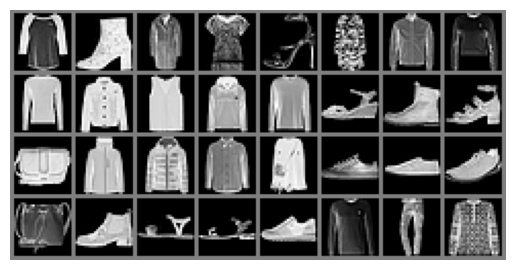

In [5]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images))

### Considerations for Dataset and Scalability

The FashionMNIST images used in this tutorial are small and may not be ideal for training a diffusion model. However, the focus here is to demonstrate how to use the TorchDiff API. You can scale up the training dataset or switch to more realistic, high-resolution, RGB images based on your specific needs.

## Training Process for the DDPM Model

Before training a Denoising Diffusion Probabilistic Model (DDPM), we need to prepare several key components required for the training process:

- **Noise Predictor ([torchdiff.utils.NoisePredictor](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.NoisePredictor))**:
  This module predicts the amount of noise added to the data and uses this prediction to denoise the data during the backward pass of the diffusion process. For more details, refer to the [TorchDiff NoisePredictor documentation](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.NoisePredictor).

- **Optimizer ([torch.optim.AdamW](https://pytorch.org/docs/stable/optim.html#torch.optim.AdamW))**:
  For training the DDPM model, we use the AdamW optimizer, which is well-suited for optimizing neural networks.

- **Loss Function ([torch.nn.MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html))**:
  This tutorial employs a simple Mean Squared Error (MSE) loss from PyTorch, which computes the difference between the predicted noise (from the NoisePredictor) and the actual noise added during the forward pass.

- **Metrics ([torchdiff.utils.Metrics](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.Metrics))**:
  This class from the TorchDiff library computes various evaluation metrics based on the specified requirements. The following metrics are supported:
  - Fréchet Inception Distance (FID) (if `fid=True`).
  - Learned Perceptual Image Patch Similarity (LPIPS) (if `lpips=True`).
  - A set of three metrics: Mean Squared Error (MSE), Peak Signal-to-Noise Ratio (PSNR), and Structural Similarity Index (SSIM) (if `metrics=True`).
  For more details, refer to the [TorchDiff Metrics documentation](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.Metrics).

In [6]:
# Initialize the NoisePredictor for the DDPM model with parameters for grayscale images
noise_predictor = NoisePredictor(
        in_channels=1,  # Single channel for grayscale images in the training data
        down_channels=[16, 32],
        mid_channels=[32, 32], 
        up_channels=[32, 16],
        down_sampling=[True, True],
        time_embed_dim=32,
        y_embed_dim=32,
        num_down_blocks=2,
        num_mid_blocks=2,
        num_up_blocks=2,
        down_sampling_factor=2
)

# Set up the AdamW optimizer for the NoisePredictor parameters with a learning rate of 1e-3
optimizer = torch.optim.AdamW(
    [p for p in noise_predictor.parameters()], lr=1e-4
)

# Initialize the Mean Squared Error (MSE) loss function
loss = nn.MSELoss()

# Configure the Metrics class for evaluation on CPU (GPUs are recommended for actual training)
metrics = Metrics(
    device="cpu",  # Using CPU for this tutorial, but GPUs are recommended for training diffusion models
    fid=False, 
    metrics=True, 
    lpips_=True
)

### Required TorchDiff DDPM Classes for Training

To train the DDPM model, this tutorial requires the following specific classes from the TorchDiff DDPM module:

- **DDPM Hyperparameters ([VarianceSchedulerDDPM](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.VarianceSchedulerDDPM))**:
  This class manages the noise schedule for the DDPM model. For more details, refer to the [TorchDiff VarianceSchedulerDDPM documentation](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.VarianceSchedulerDDPM).

- **Reverse Diffusion ([ReverseDDPM](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.ReverseDDPM))**:
  This class is used during the sampling process to perform reverse diffusion. For more details, refer to the [TorchDiff ReverseDDPM documentation](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.ReverseDDPM).

- **DDPM Trainer ([TrainDDPM](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.TrainDDPM))**:
  This class handles the training of the prepared DDPM model. For more details, refer to the [TorchDiff TrainDDPM documentation](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.TrainDDPM).

In [7]:
# Initialize DDPM variance-scheduler for the noise schedule
variance_scheduler_ddpm = VarianceSchedulerDDPM(
    num_steps=500, 
    beta_start=1e-4, 
    beta_end=0.02,
    trainable_beta=False, # Whether the beta schedule is trainable
    beta_method="linear"
)

# Set up the forward and reverse diffusion process
forward_ddpm = ForwardDDPM(variance_scheduler_ddpm)
reverse_ddpm = ReverseDDPM(variance_scheduler_ddpm)


# Configure the DDPM trainer for model training
train_ddpm = TrainDDPM(
    noise_predictor=noise_predictor,
    forward_diffusion=forward_ddpm,
    reverse_diffusion=reverse_ddpm,
    data_loader=train_loader,
    optimizer=optimizer,
    objective=loss,
    val_loader=val_loader,
    max_epochs=10,
    device="cpu",
    conditional_model=None,
    metrics_=metrics,
    bert_tokenizer=None,
    max_token_length=77,
    store_path="test_ddpm",
    val_frequency=6,
    image_output_range=(-1.0, 1.0),
    normalize_output=True,
    use_ddp=False,
    grad_accumulation_steps=2,
    log_frequency=1,
    use_compilation=False
)

In [8]:
# start trining
train_losses, best_val_loss = train_ddpm()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [01:36<00:00, 13.80s/it]



Epoch: 1/10 | LR: 3.00e-06 | Train Loss: 1.2970



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [01:44<00:00, 14.88s/it]



Epoch: 2/10 | LR: 6.00e-06 | Train Loss: 1.2910



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [01:42<00:00, 14.66s/it]


...


Epoch: 8/10 | LR: 2.40e-05 | Train Loss: 1.1740



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [01:38<00:00, 14.09s/it]



Epoch: 9/10 | LR: 2.70e-05 | Train Loss: 1.1619



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [01:36<00:00, 13.71s/it]


Epoch: 10/10 | LR: 3.00e-05 | Train Loss: 1.1465



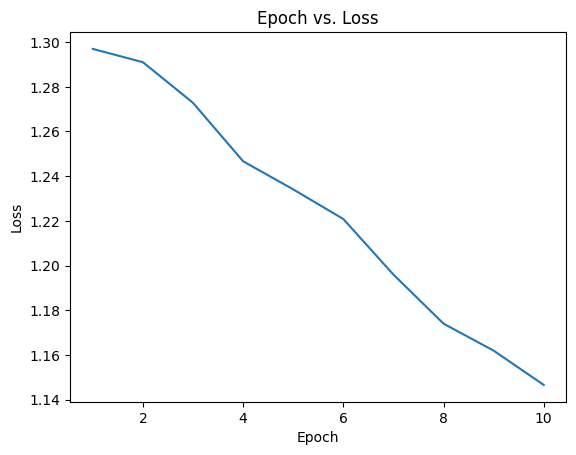

In [12]:
plt.plot([i for i in range(1, 11)], train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs. Loss")
plt.show()

## Sampling Process for the DDPM Model

After training the DDPM model, we can generate new images. While we can directly use the trained model, it is common to load the trained parameters of the denoising model and generate new data using the [torchdiff.ddpm.SampleDDPM](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.SampleDDPM) class. In this tutorial, we will load the trained parameters and generate new images.

In [15]:
# Initialize a new NoisePredictor with the same architecture as the trained model
new_noise_predictor = NoisePredictor(
    in_channels=1,  # Single channel for grayscale images
    down_channels=[16, 32],
    mid_channels=[32, 32], 
    up_channels=[32, 16],
    down_sampling=[True, True],
    time_embed_dim=32,
    y_embed_dim=32,
    num_down_blocks=2,
    num_mid_blocks=2,
    num_up_blocks=2,
    down_sampling_factor=2
)

# Initialize DDPM hyperparameters for the noise schedule
new_variance_scheduler_ddpm = VarianceSchedulerDDPM(
    num_steps=500, 
    beta_start=1e-4, 
    beta_end=0.02, 
    beta_method="linear"
)

# Set up the new reverse diffusion process for sampling
new_reverse_ddpm = ReverseDDPM(variance_scheduler_ddpm)


# Load the trained model checkpoint from file
checkpoint = torch.load('test_ddpm/ddpm_epoch_6.pth', map_location='cpu')

# Load the trained parameters into the new NoisePredictor and set to evaluation mode
new_noise_predictor.load_state_dict(checkpoint['model_state_dict_noise_predictor'])
new_noise_predictor.eval()

new_reverse_ddpm.variance_scheduler.load_state_dict(checkpoint['variance_scheduler_model'])

<All keys matched successfully>

In [14]:
# sampling process
sampler = SampleDDPM(
    reverse_diffusion=new_reverse_ddpm,
    noise_predictor=new_noise_predictor,
    image_shape=(28, 28),
    conditional_model=None,
    tokenizer="bert-base-uncased",
    max_token_length=77,
    batch_size=10, # generate 10 new images
    in_channels=1,
    device="cpu",
    image_output_range=(-1, 1)
)

In [16]:
gen_imgs = sampler(save_images=True, save_path="ddpm_generated") # the created images will be stored in the given directory

### Visualizing Generated Images

In this section, we will visualize the images generated by the trained DDPM model to inspect the results of the sampling process.

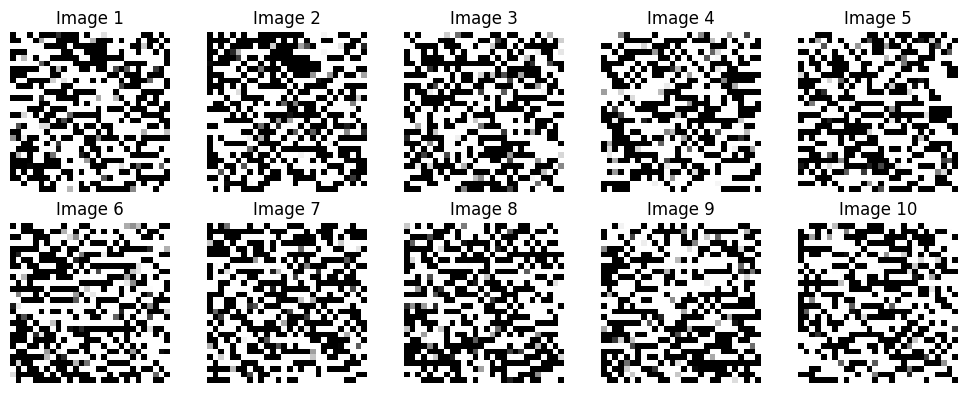

In [17]:
folder_path = "ddpm_generated"
num_images = 10 
rows, cols = 2, 5

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

for i in range(num_images):
    img_path = os.path.join(folder_path, f"image_{i+1}.png")
    img = Image.open(img_path).convert('L')  # 'L' = grayscale

    ax = axes[i // cols, i % cols]
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Image {i+1}")

plt.tight_layout()
plt.show()

### Evaluating the Generated Images

The generated images may not be optimal, as we trained a shallow DDPM model for only five epochs on a small subset of the FashionMNIST dataset. This limited training setup is intended to demonstrate the TorchDiff API rather than achieve high-quality results.

## Useful Resources

The following links provide additional information and resources for working with the TorchDiff library:

- [TorchDiff Webpage](https://loqmansamani.github.io/torchdiff/): The official webpage for the TorchDiff library.
- [TorchDiff GitHub Repository](https://github.com/loqmansamani/torchdiff): The source code and documentation for TorchDiff.
- [TorchDiff API Documentation](https://torchdiff.readthedocs.io/en/latest/index.html): The official API reference for TorchDiff.
- [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239)
- [TorchDiff: A PyTorch Library for Denoising Diffusion Probabilistic Models and Beyond](https://medium.com/@samaniloqman91/torchdiff-a-pytorch-library-for-denoising-diffusion-probabilistic-models-and-beyond-d15156e9e3b5)